In [1]:
import os
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
USE_MS = True

In [3]:
log_dir = "accuracy_data/"
log_files = [f"{log_dir}/{i}" for i in os.listdir(log_dir) if (not i.startswith(".") and i.endswith(".txt"))]
# log_files

In [4]:
data = {}
for path in log_files:
    file_data = []
    filename = path.rsplit('.', 1)[0].rsplit('/', 1)[1].split("_")
    application = filename[0]
    rate = float(filename[1])
    if USE_MS:
        rate *= 1000.0
    with open(path, 'r') as f:
        lines = f.readlines()
    prev = None
    for line in lines:
        line = line.strip()
        if ':' not in line:
            continue
        ts = line.split(' ')[0].split(':')
        if len(ts) < 3:
            continue
        hour = float(ts[0])
        minute = float(ts[1])
        second = float(ts[2])
        second += 60*minute
        second += 60*60*hour
        ms = second*1000.0
        if prev is not None:
            if USE_MS:
                diff = ms - prev
            else:
                diff = second - prev
            file_data.append(diff)
        prev = ms
    if application not in data:
        data[application] = {}
    data[application][rate] = file_data



In [5]:
# df = pd.DataFrame(
#     [
#         {"expected": expected, "measured": measured, "error": measured-expected}
#         for expected, measurements in data.items()
#         for measured in measurements
#     ]
# )
df = pd.DataFrame(
    [
        {"Application": application, "Expected": expected, "Measured": measured, "Error": measured-expected}
        for application, intervals in data.items()
        for expected, measurements in intervals.items()
        for measured in measurements
    ]
)

In [6]:
df

,Application,Expected,Measured,Error
0,pping,950.0,950.265,0.265
1,pping,950.0,950.193,0.193
2,pping,950.0,950.136,0.136
3,pping,950.0,950.163,0.163
4,pping,950.0,950.143,0.143
...,...,...,...,...
733,ping,950.0,959.915,9.915
734,ping,950.0,959.972,9.972
735,ping,950.0,960.007,10.007
736,ping,950.0,960.028,10.028


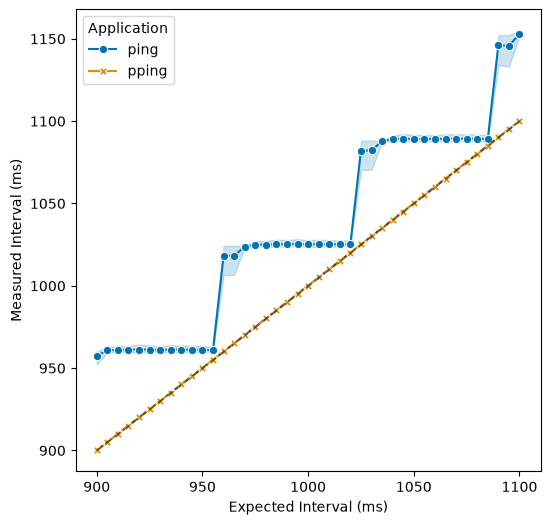

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.lineplot(
    ax=ax,
    data=df,
    x="Expected",
    y="Measured",
    hue="Application",
    hue_order=["ping", "pping"],
    style="Application",
    style_order=["ping", "pping"],
    markers=True,
    dashes=False,
    palette="colorblind"
)
xmin = df["Expected"].min()
xmax = df["Expected"].max()
ax.plot([xmin, xmax], [xmin, xmax], "k--", label="y=x", alpha=0.5)
ax.set_xlabel("Expected Interval (ms)")
ax.set_ylabel("Measured Interval (ms)")
ax.xaxis.set_major_locator(MultipleLocator(50))

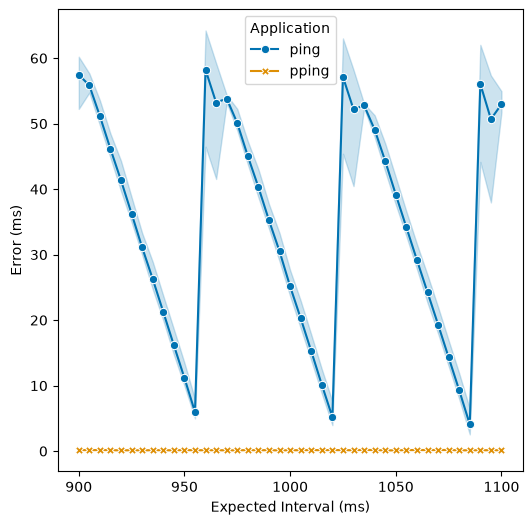

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.lineplot(
    ax=ax,
    data=df,
    x="Expected",
    y="Error",
    hue="Application",
    hue_order=["ping", "pping"],
    style="Application",
    style_order=["ping", "pping"],
    markers=True,
    dashes=False,
    palette="colorblind"
)
ax.set_xlabel("Expected Interval (ms)")
ax.set_ylabel("Error (ms)")
ax.xaxis.set_major_locator(MultipleLocator(50))

In [9]:
stats = df.groupby("Application")["Error"].agg(["min", "mean", "max"])
print("Error Statistics (ms):")
stats

Error Statistics (ms):


,min,mean,max
Application,,,
ping,0.347,34.914753,64.947
pping,0.061,0.149561,0.294
